# For the base datasets

In [17]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

In [6]:
restaurants = pd.read_parquet("../Datasets/florida_restaurants_df.parquet")
restaurants.head(1)

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url
0,Cape Seafood Shack,"Cape Seafood Shack, 603 Del Prado Blvd S, Cape...",0x88db4147b1d9e6f3:0x943dbd10a92ba1b1,None,26.641377,-81.940545,[Restaurant],5.0,1,$$,None,{'Accessibility': ['Wheelchair accessible entr...,None,None,https://www.google.com/maps/place//data=!4m2!3...


In [34]:
from sklearn.preprocessing import StandardScaler

data = restaurants[["latitude","longitude"]].values
print (data)
scaler = StandardScaler()
print(scaler.fit(data))
print(scaler.mean_)
scaled_data = scaler.transform(data)

[[ 26.641377  -81.9405452]
 [ 30.3914113 -87.2672203]
 [ 29.7269487 -84.9815347]
 ...
 [ 25.7286805 -80.2620893]
 [ 25.8482952 -80.1747993]
 [ 25.5061208 -80.4382145]]
StandardScaler()
[ 27.74399795 -81.64998753]


In [50]:
from sklearn.cluster import DBSCAN
import numpy as np

clustering = DBSCAN(eps=0.01, min_samples=5).fit(scaled_data)
labels = clustering.labels_
print(clustering.labels_)

[ 0 -1 -1 ...  2  2 -1]


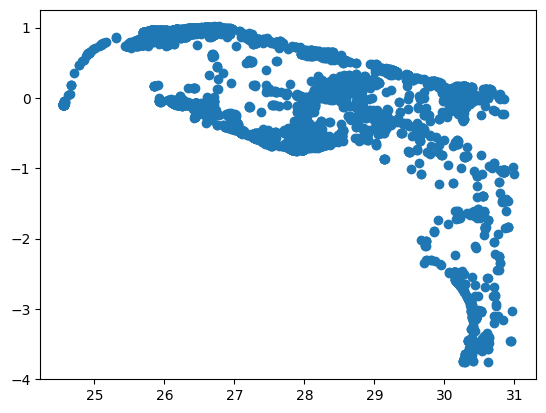

In [51]:
plt.scatter(data[:, 0], scaled_data[:, 1])
plt.show()

<h3>Distribucion general de los datos</h3>

In [52]:

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 274
Estimated number of noise points: 2027


In [53]:
from sklearn import metrics

print(f"Silhouette Coefficient: {metrics.silhouette_score(scaled_data, labels):.3f}")

Silhouette Coefficient: 0.002


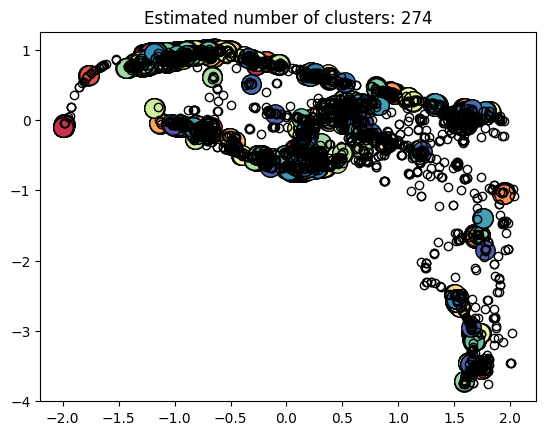

In [63]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[clustering.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, .0]

    class_member_mask = labels == k

    xy = scaled_data[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = scaled_data[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [65]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=100, random_state=0, n_init="auto").fit(scaled_data)
kmeans.labels_
print(kmeans.predict([[0, 0], [12, 3]]))
print(kmeans.cluster_centers_)


[28 37]
[[ 9.77534616e-02 -4.19963785e-01]
 [-1.25710465e+00  8.65276273e-01]
 [ 1.52228084e+00 -2.51489936e+00]
 [ 1.34042408e+00  2.05216251e-01]
 [ 3.69521271e-01  1.65504755e-01]
 [-9.69309962e-01 -7.05495842e-02]
 [-6.41298771e-01  9.93687742e-01]
 [ 1.80405991e+00 -3.41330070e+00]
 [ 1.36477406e+00 -1.13102190e+00]
 [ 8.92776141e-01 -3.12784280e-01]
 [-1.98628170e+00 -6.60740282e-02]
 [ 2.14621345e-01  6.40994853e-01]
 [-1.59122099e-01 -5.80847416e-01]
 [ 6.09238973e-01  1.83511492e-01]
 [ 1.53322129e+00 -6.74910894e-02]
 [-9.48270646e-01  8.90558664e-01]
 [ 1.67627262e+00 -1.65629852e+00]
 [ 3.05307483e-01 -6.62584881e-01]
 [ 1.18503759e+00 -4.58044601e-01]
 [-4.86835578e-01 -2.74168448e-01]
 [ 9.26084421e-01  3.83294932e-01]
 [ 1.90129613e+00 -1.03945528e+00]
 [-1.83886045e-01  8.22919368e-01]
 [ 1.67003247e+00 -3.02115153e+00]
 [ 1.64349969e-01 -2.05138891e-01]
 [-1.16426915e+00  9.23246653e-01]
 [ 1.69588389e+00 -3.51229626e+00]
 [ 6.89712237e-01 -2.12587473e-01]
 [-1.3002678

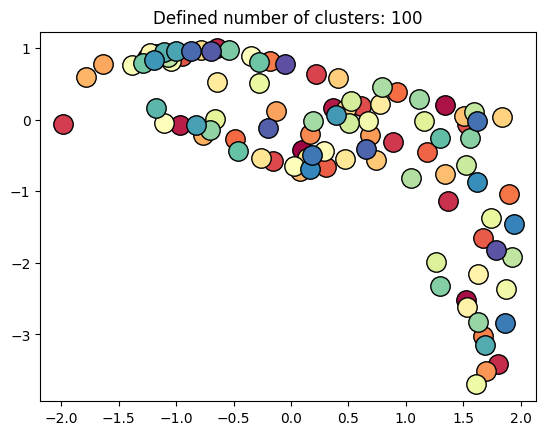

In [ ]:

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(kmeans.cluster_centers_))]
for k, col in zip(kmeans.cluster_centers_, colors):

    plt.plot(
        k[0],
        k[1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

plt.title(f"Defined number of clusters: {len(kmeans.cluster_centers_)}")
plt.show()